In [1]:
import torch
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("Ultralytics OK")


Torch: 2.9.1+cu128
Ultralytics OK


In [2]:
import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

for clase in os.listdir(dataset_path):
    clase_path = os.path.join(dataset_path, clase)
    if os.path.isdir(clase_path):
        print(clase, ":", len(os.listdir(clase_path)))


train : 4
valid : 4
test : 4


In [3]:
from ultralytics import YOLO

# Cargar un modelo de clasificación preentrenado
# yolo11n-cls.pt para velocidad o yolo11m-cls.pt para precisión

model = YOLO('yolo11m-cls.pt') 

# Entrenar el modelo
results = model.train(
 data='Banana Ripeness Classification.v2-original-images_modifiedclasses.folder', # Ruta a la carpeta raíz del dataset descargado
 epochs=20, # Número de iteraciones
 imgsz=224, # Tamaño de la imagen
 device=0 # Usar GPU (si está disponible)
)

New https://pypi.org/project/ultralytics/8.4.6 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16083MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Banana Ripeness Classification.v2-original-images_modifiedclasses.folder, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.0,

In [4]:
# Realizar predicción 
results = model('./ImagenesPrueba/bueno.jpeg')

# Mostrar resultados 
for result in results: 
    print(result.probs)  # Probabilidades de cada clase


image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/bueno.jpeg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 3.9ms
Speed: 1.4ms preprocess, 3.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.4915e-06, 9.9954e-01, 4.6062e-04, 1.4297e-07], device='cuda:0')
orig_shape: None
shape: torch.Size([4])
top1: 1
top1conf: tensor(0.9995, device='cuda:0')
top5: [1, 2, 0, 3]
top5conf: tensor([9.9954e-01, 4.6062e-04, 2.4915e-06, 1.4297e-07], device='cuda:0')


In [5]:
# Análisis del Dataset

import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

print("=" * 50)
print("ANÁLISIS DEL DATASET")
print("=" * 50)

for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset_path, split)
    print(f"\n{split.upper()}:")
    
    total = 0
    for clase in os.listdir(split_path):
        clase_path = os.path.join(split_path, clase)
        if os.path.isdir(clase_path):
            num_images = len(os.listdir(clase_path))
            total += num_images
            print(f"  - {clase}: {num_images} imágenes")
    
    print(f"  TOTAL: {total} imágenes")

print("\n" + "=" * 50)

ANÁLISIS DEL DATASET

TRAIN:
  - overripe: 783 imágenes
  - rotten: 1340 imágenes
  - unripe: 634 imágenes
  - ripe: 1174 imágenes
  TOTAL: 3931 imágenes

VALID:
  - overripe: 229 imágenes
  - rotten: 388 imágenes
  - unripe: 167 imágenes
  - ripe: 339 imágenes
  TOTAL: 1123 imágenes

TEST:
  - overripe: 113 imágenes
  - rotten: 185 imágenes
  - unripe: 110 imágenes
  - ripe: 154 imágenes
  TOTAL: 562 imágenes



RESULTADOS DEL ENTRENAMIENTO


Results.Png


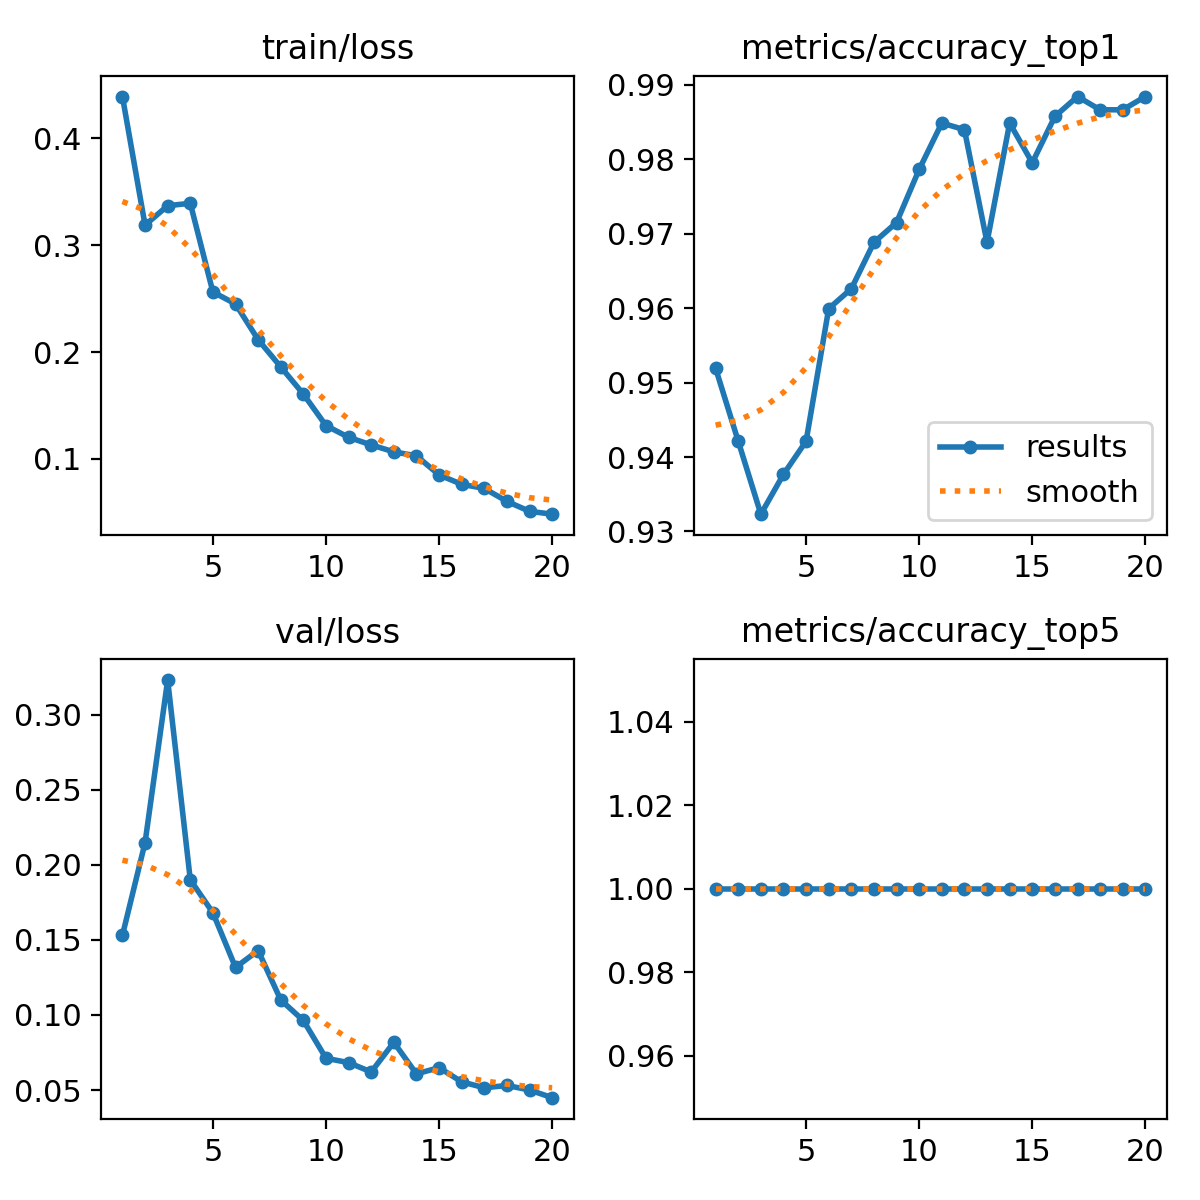


Confusion Matrix.Png


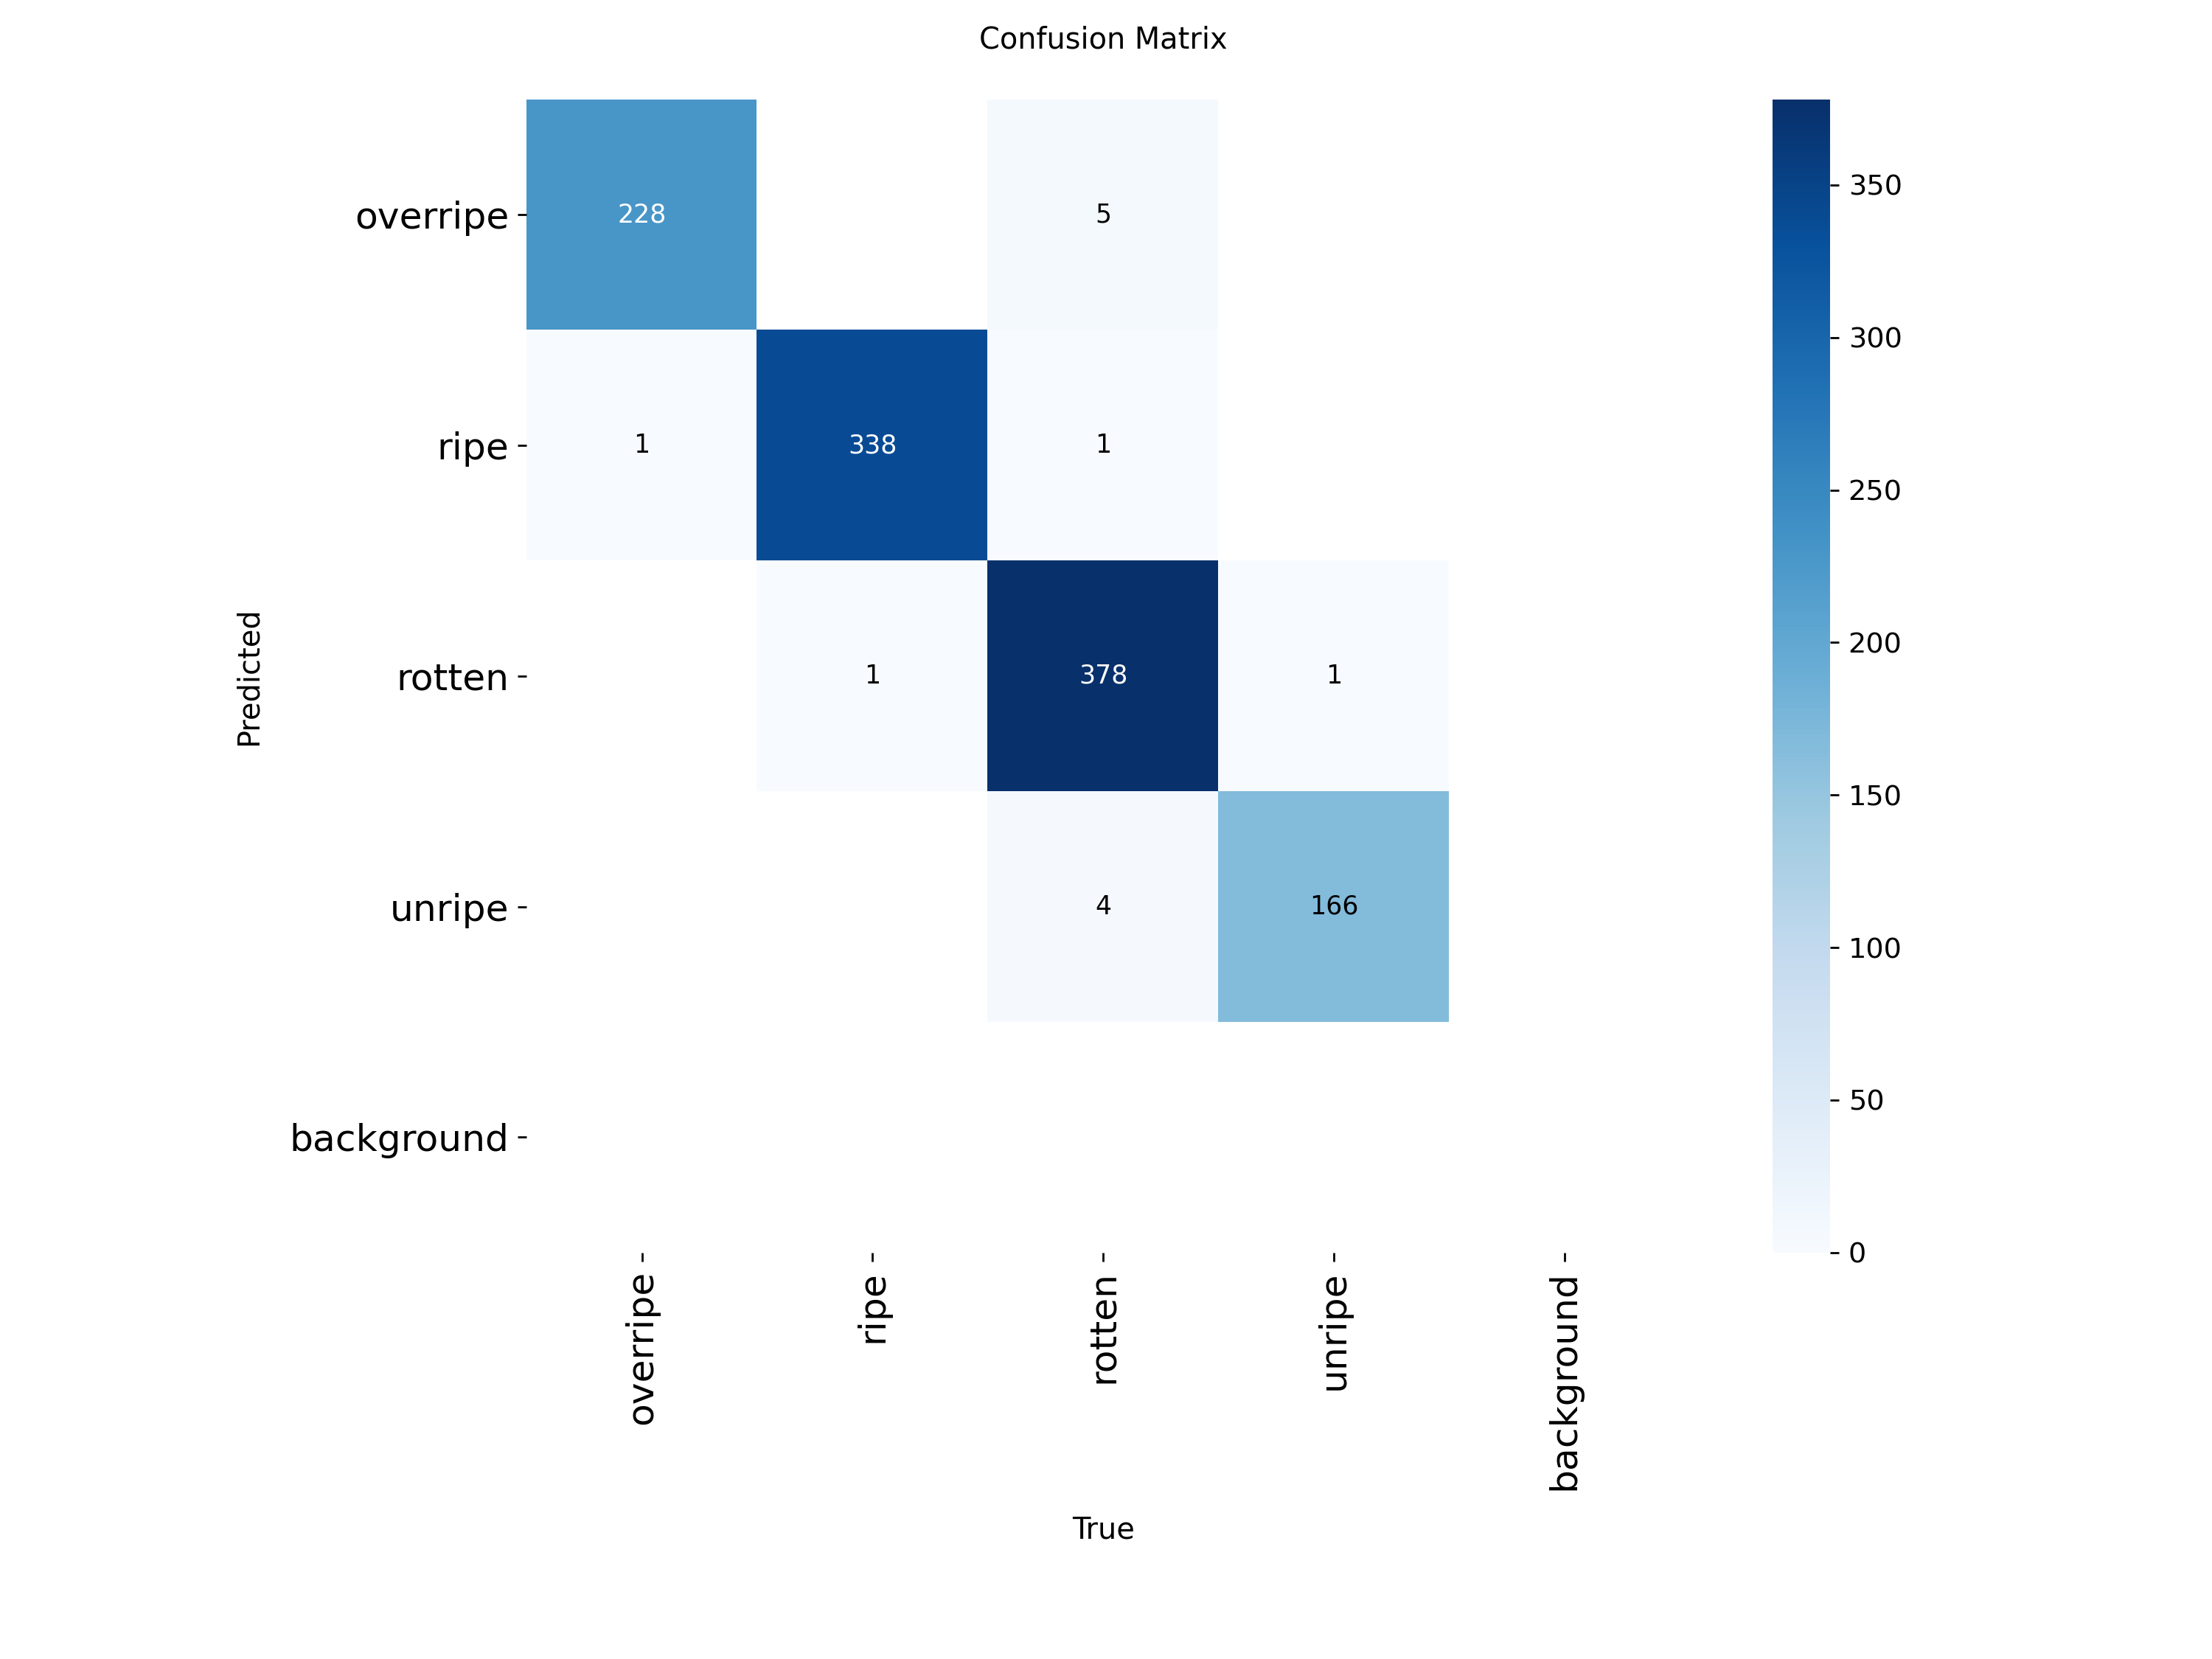


Confusion Matrix Normalized.Png


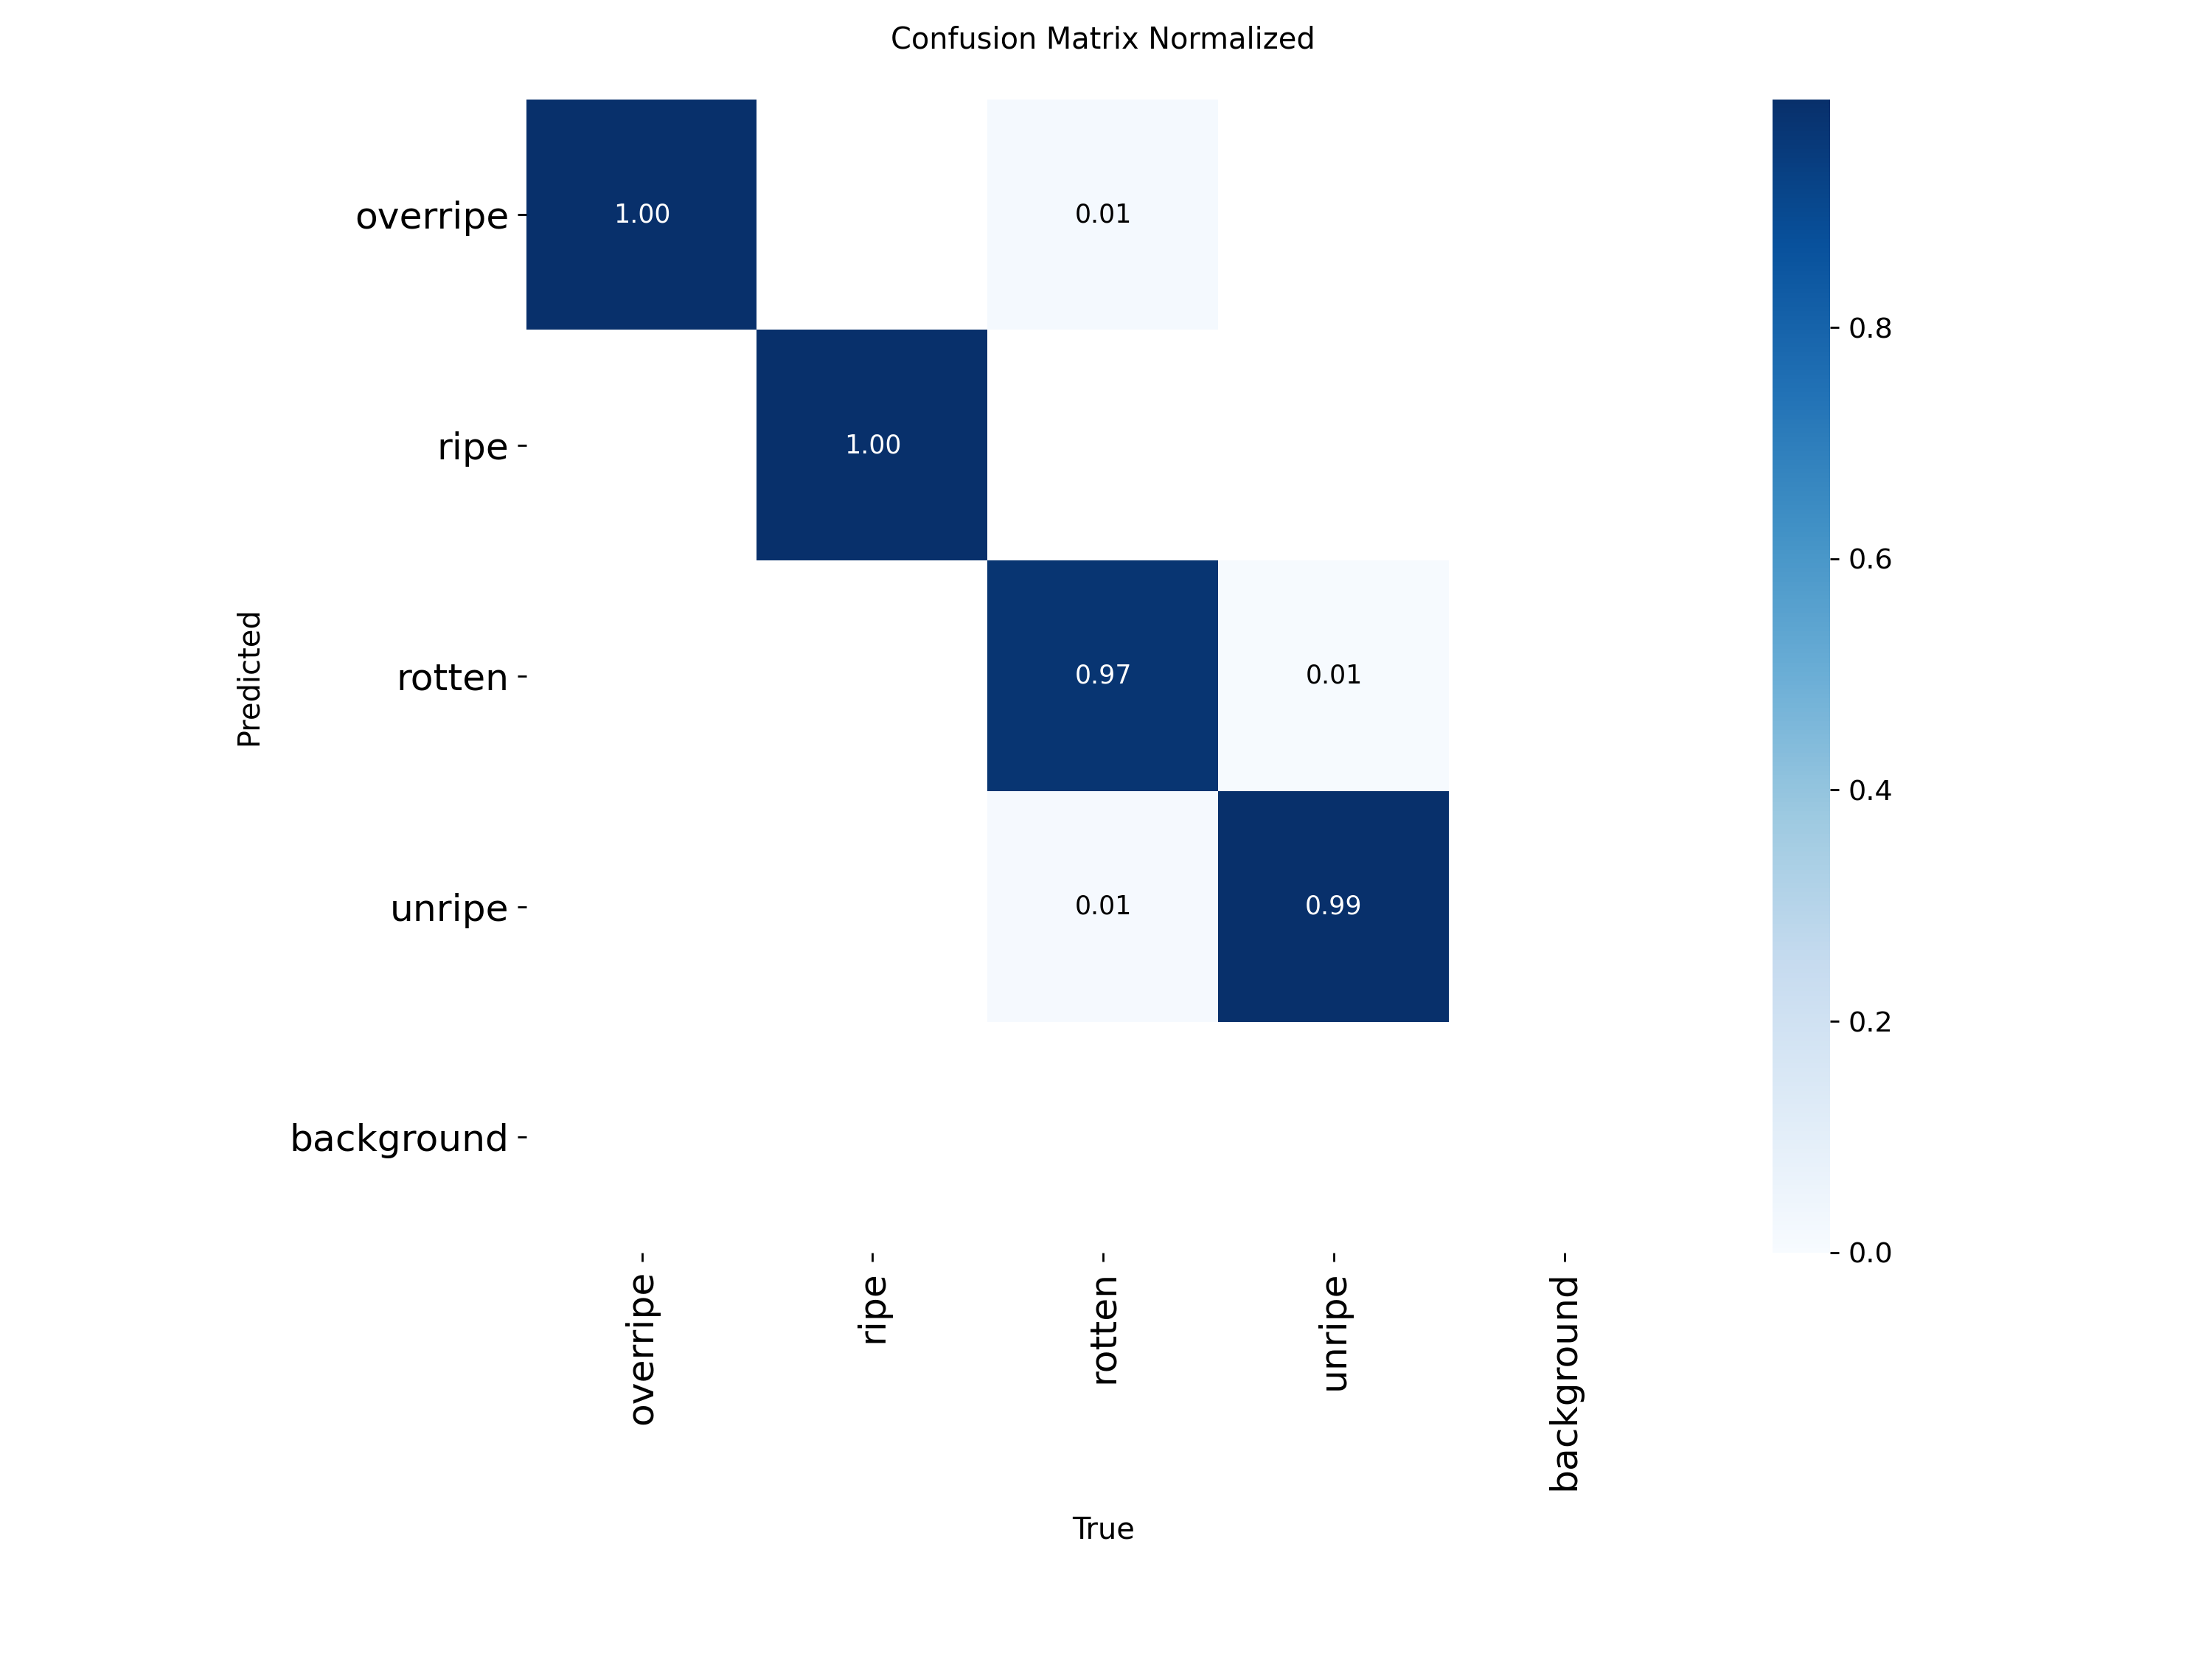

In [6]:
# Visualizar las Métricas de Entrenamiento

from IPython.display import Image, display
import os

print("RESULTADOS DEL ENTRENAMIENTO\n")

# Ruta a los resultados
results_path = "runs/classify/train"

# Mostrar las gráficas generadas
graficas = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']

for grafica in graficas:
    ruta = os.path.join(results_path, grafica)
    if os.path.exists(ruta):
        print(f"\n{'='*50}")
        print(f"{grafica.replace('_', ' ').title()}")
        print('='*50)
        display(Image(filename=ruta))

In [6]:
# Análisis de la Matriz de Confusión

print("\n" + "="*60)
print("ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print("="*60)

print("""\nLas clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)
      
La matriz de confusión muestra el rendimiento del modelo de clasificación comparando las 
etiquetas reales con las predicciones realizadas. Cada fila representa la clase real 
y cada columna la clase predicha. Los valores de la diagonal indican las predicciones 
correctas, mientras que los valores fuera de la diagonal representan errores de clasificación.
      
El modelo presenta mayor confusión entre las clases “ripe” (madura) y “overripe” (pasada). 
Esto se debe a que visualmente ambas clases comparten características similares como 
el color amarillo intenso y la presencia de manchas oscuras.
      
La clase “overripe” es la que presenta mayor dificultad de clasificación, ya que sus 
características visuales pueden solaparse tanto con plátanos maduros como con 
imágenes mal iluminadas o con sombras.""")




ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Las clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)

La matriz de confusión muestra el rendimiento del modelo de clasificación comparando las 
etiquetas reales con las predicciones realizadas. Cada fila representa la clase real 
y cada columna la clase predicha. Los valores de la diagonal indican las predicciones 
correctas, mientras que los valores fuera de la diagonal representan errores de clasificación.

El modelo presenta mayor confusión entre las clases “ripe” (madura) y “overripe” (pasada). 
Esto se debe a que visualmente ambas clases comparten características similares como 
el color amarillo intenso y la presencia de manchas oscuras.

La clase “overripe” es la que presenta mayor dificultad de clasificación, ya que sus 
características visuales pueden solaparse tanto con plátanos maduros como con 
imágenes mal iluminadas o con sombras.


In [ ]:
# Pruebas con Imágenes Reales

import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Lista de imágenes a probar
imagenes_prueba = [
    './ImagenesPrueba/bueno.jpeg',
    './ImagenesPrueba/maduro.jpeg',
    './ImagenesPrueba/normal.jpeg'
]

# Nombres de las clases (en el orden del modelo)
# overripe(sobremaduro/pasado) ripe(maduro) rotten(podrido) unripe(verde)
nombres_clases = ['overripe', 'ripe', 'rotten', 'unripe']

print("PRUEBAS CON IMÁGENES NUEVAS\n")

for i, img_path in enumerate(imagenes_prueba, 1):
    print(f"\n{'='*60}")
    print(f"IMAGEN {i}: {img_path}")
    print('='*60)
    
    # Realizar predicción
    results = model(img_path)
    
    # Obtener las probabilidades
    probs = results[0].probs.data.cpu().numpy()
    
    # Clase predicha
    clase_predicha = nombres_clases[probs.argmax()]
    confianza = probs.max() * 100
    
    print(f"\nPredicción: {clase_predicha.upper()}")
    print(f"Confianza: {confianza:.2f}%")
    print(f"\nProbabilidades por clase:")
    for nombre, prob in zip(nombres_clases, probs):
        print(f"  - {nombre}: {prob*100:.2f}%")
    
    # Mostrar la imagen
    plt.figure(figsize=(8, 6))
    img = PILImage.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicción: {clase_predicha} ({confianza:.1f}%)", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
# Evaluación
print("""Imagen 1
Clase predicha: ripe
¿Acertó la predicción?: SÍ
Explicación: El plátano presenta un color amarillo uniforme y sin manchas significativas, 
lo cual coincide con la clase madura.

Imagen 2
Clase predicha: unripe
¿Acertó la predicción?: SÍ
Explicación: La imagen muestra un plátano mayoritariamente verde, característica clara de un plátano no maduro.

Imagen 3
Clase predicha: overripe
¿Acertó la predicción?: NO
Explicación: Aunque el modelo lo clasificó como pasado, el plátano parecía simplemente maduro. 
La iluminación y las sombras pudieron influir negativamente en la predicción.""")


PRUEBAS CON IMÁGENES NUEVAS


IMAGEN 1: ./ImagenesPrueba/bueno.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/bueno.jpeg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 2.9ms
Speed: 9.2ms preprocess, 2.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

Predicción: RIPE
Confianza: 99.95%

Probabilidades por clase:
  - overripe: 0.00%
  - ripe: 99.95%
  - rotten: 0.05%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>


IMAGEN 2: ./ImagenesPrueba/maduro.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/maduro.jpeg: 224x224 rotten 0.86, overripe 0.14, ripe 0.00, unripe 0.00, 2.2ms
Speed: 1.5ms preprocess, 2.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Predicción: ROTTEN
Confianza: 85.63%

Probabilidades por clase:
  - overripe: 14.37%
  - ripe: 0.00%
  - rotten: 85.63%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>


IMAGEN 3: ./ImagenesPrueba/normal.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/normal.jpeg: 224x224 rotten 0.94, overripe 0.06, ripe 0.00, unripe 0.00, 2.9ms
Speed: 1.2ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

Predicción: ROTTEN
Confianza: 93.99%

Probabilidades por clase:
  - overripe: 6.01%
  - ripe: 0.00%
  - rotten: 93.99%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>

Imagen 1
Clase predicha: ripe
¿Acertó la predicción?: SÍ
Explicación: El plátano presenta un color amarillo uniforme y sin manchas significativas, 
lo cual coincide con la clase madura.

Imagen 2
Clase predicha: unripe
¿Acertó la predicción?: SÍ
Explicación: La imagen muestra un plátano mayoritariamente verde, característica clara de un plátano no maduro.

Imagen 3
Clase predicha: overripe
¿Acertó la predicción?: NO
Explicación: Aunque el modelo lo clasificó como pasado, el plátano parecía simplemente maduro. 
La iluminación y las sombras pudieron influir negativamente en la predicción.


In [1]:
# Métricas Finales del Modelo

print("\n" + "="*60)
print("RESUMEN DE MÉTRICAS FINALES")
print("="*60)

print(f"""\nConfiguración del entrenamiento
Modelo: YOLO11m-cls (Medium – mayor precisión)
Número de épocas: 20
Tamaño de imagen: 224 × 224
Optimizador: AdamW
Dispositivo: GPU (CUDA)

Resultados obtenidos
El modelo alcanza una accuracy en validación cercana al 99%, lo que indica un excelente rendimiento 
en la clasificación del estado de madurez de los plátanos.

La evolución de la función de pérdida (loss) muestra una disminución progresiva a lo largo de las 
épocas, lo que sugiere un aprendizaje estable sin signos evidentes de sobreajuste.

Al analizar la matriz de confusión, se observa que la mayoría de las imágenes son clasificadas 
correctamente. Los pocos errores se producen principalmente entre clases visualmente similares, 
como plátanos maduros y pasados.

Interpretación
El uso del modelo YOLO11m-cls permite obtener una alta precisión gracias a su mayor capacidad en 
comparación con versiones más ligeras, a costa de un mayor tiempo de entrenamiento.""")


RESUMEN DE MÉTRICAS FINALES

Configuración del entrenamiento
Modelo: YOLO11m-cls (Medium – mayor precisión)
Número de épocas: 20
Tamaño de imagen: 224 × 224
Optimizador: AdamW
Dispositivo: GPU (CUDA)

Resultados obtenidos
El modelo alcanza una accuracy en validación cercana al 99%, lo que indica un excelente rendimiento 
en la clasificación del estado de madurez de los plátanos.

La evolución de la función de pérdida (loss) muestra una disminución progresiva a lo largo de las 
épocas, lo que sugiere un aprendizaje estable sin signos evidentes de sobreajuste.

Al analizar la matriz de confusión, se observa que la mayoría de las imágenes son clasificadas 
correctamente. Los pocos errores se producen principalmente entre clases visualmente similares, 
como plátanos maduros y pasados.

Interpretación
El uso del modelo YOLO11m-cls permite obtener una alta precisión gracias a su mayor capacidad en 
comparación con versiones más ligeras, a costa de un mayor tiempo de entrenamiento.


In [4]:
# Conclusiones

print("\n" + "="*60)
print("CONCLUSIONES")
print("="*60)

print("""\nRendimiento del modelo

El modelo YOLO11m-cls ofrece un excelente rendimiento general gracias a su mayor capacidad de 
aprendizaje en comparación con versiones más ligeras. 
La precisión es especialmente alta en clases claramente diferenciables visualmente, como unripe, 
y se mantiene elevada incluso en clases más similares.

Factores que afectan a la precisión
Los principales factores que influyen en el rendimiento del modelo son:

Iluminación irregular
Fondos complejos o con colores similares al plátano
Calidad y resolución de la imagen
Similitud visual entre clases (especialmente entre plátanos maduros y pasados)

Posibles mejoras
Para mejorar aún más la precisión del modelo se podrían aplicar las siguientes estrategias:

Aumentar el tamaño y la diversidad del dataset
Aplicar técnicas de data augmentation
Ajustar el número de épocas para optimizar el entrenamiento
Probar modelos con mayor capacidad como yolo11l-cls en escenarios donde el coste computacional 
no sea un problema

Elección del modelo
Se eligió yolo11m-cls como compromiso entre precisión y coste computacional. 
Este modelo ofrece mejores resultados que versiones más ligeras, manteniendo tiempos de entrenamiento 
y de inferencia razonables.""")



CONCLUSIONES

Rendimiento del modelo

El modelo YOLO11m-cls ofrece un excelente rendimiento general gracias a su mayor capacidad de 
aprendizaje en comparación con versiones más ligeras. 
La precisión es especialmente alta en clases claramente diferenciables visualmente, como unripe, 
y se mantiene elevada incluso en clases más similares.

Factores que afectan a la precisión
Los principales factores que influyen en el rendimiento del modelo son:

Iluminación irregular
Fondos complejos o con colores similares al plátano
Calidad y resolución de la imagen
Similitud visual entre clases (especialmente entre plátanos maduros y pasados)

Posibles mejoras
Para mejorar aún más la precisión del modelo se podrían aplicar las siguientes estrategias:

Aumentar el tamaño y la diversidad del dataset
Aplicar técnicas de data augmentation
Ajustar el número de épocas para optimizar el entrenamiento
Probar modelos con mayor capacidad como yolo11l-cls en escenarios donde el coste computacional 
no sea un